# Análisis del comportamiento histórico de Bitcoin: riesgo, volatilidad y dinámica de volumen

### Abstract

Bitcoin se ha consolidado como el principal activo digital del mercado, caracterizado por elevados niveles de volatilidad y un comportamiento influenciado por la dinámica de oferta y demanda. Si bien su rentabilidad histórica ha sido notable, también ha presentado fuertes movimientos extremos que lo convierten en un activo de alto riesgo relativo.

El presente proyecto tiene como objetivo analizar el comportamiento histórico de Bitcoin utilizando datos obtenidos desde una API pública. Se estudiará la distribución de sus retornos diarios, su nivel de volatilidad, la magnitud de sus caídas acumuladas y la relación entre movimientos de precio y volumen negociado.

La audiencia objetivo incluye inversores minoristas, analistas financieros junior y profesionales interesados en comprender, desde una perspectiva cuantitativa, el perfil de riesgo del activo.

## Preguntas de investigación

1. ¿Cómo se distribuyen los retornos diarios de Bitcoin?

2. ¿Cuál es su nivel de volatilidad diaria y anual?

3. ¿Con qué frecuencia ocurren movimientos extremos?

4. ¿Cuál ha sido la magnitud de sus principales caídas acumuladas?

5. ¿Existe relación entre variaciones fuertes de precio y cambios en el volumen negociado?

6. ¿El volumen aumenta durante períodos de alta volatilidad?





## Obtención de datos históricos mediante Yahoo Finance

Dado que la API pública de CoinGecko limita el acceso a datos históricos completos, se utilizará la librería yfinance, que permite descargar información histórica de mercado directamente desde Yahoo Finance.

Se obtendrán datos diarios de Bitcoin (BTC-USD), incluyendo:

* Precio de apertura

* Precio máximo

* Precio mínimo

* Precio de cierre

* Volumen negociado

In [1]:
# IMPORTACION DE LIBRERIAS
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use("default")


In [2]:
# Instalamos la libreira

!pip install -qq yfinance

import yfinance as yf

# Descargamos datos históricos completos
df = yf.download("BTC-USD", start="2015-01-01")

df.reset_index(inplace=True)

df.to_csv("bitcoin_historico.csv", index=False)

df.head()

/tmp/ipykernel_22043/3334781387.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2015-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


Resumen del dataset

Antes de comenzar con el análisis exploratorio, se presenta un resumen general del dataset obtenido, incluyendo cantidad de observaciones, variables disponibles y período temporal cubierto.

In [3]:
# Dimensiones del dataset
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])
print("\n")

# Tipos de datos
print("Tipos de variables:")
print(df.dtypes)
print("\n")

# Rango temporal
print("Fecha mínima:", df["Date"].min())
print("Fecha máxima:", df["Date"].max())


Cantidad de filas: 4128
Cantidad de columnas: 6


Tipos de variables:
Price   Ticker 
Date               datetime64[ns]
Close   BTC-USD           float64
High    BTC-USD           float64
Low     BTC-USD           float64
Open    BTC-USD           float64
Volume  BTC-USD             int64
dtype: object


Fecha mínima: 2015-01-01 00:00:00
Fecha máxima: 2026-04-21 00:00:00


Limpieza y verificación de datos

Se verificará la existencia de valores nulos y se preparará el dataset para el análisis posterior.

In [4]:
# Verificamos valores nulos
df.isnull().sum()


,,0
Price,Ticker,
Date,,0
Close,BTC-USD,0
High,BTC-USD,0
Low,BTC-USD,0
Open,BTC-USD,0
Volume,BTC-USD,0


### Ingeniería de atributos

Con el objetivo de enriquecer el análisis, se crearán nuevas variables derivadas del precio y del volumen. Estas permitirán estudiar el comportamiento del activo desde una perspectiva de riesgo y dinámica de mercado.

Se calcularán:

* Retorno diario porcentual

* Retorno acumulado

* Volatilidad móvil (30 días)

* Variación porcentual del volumen

* Identificación de eventos extremos

* Identificación de caídas severas

In [5]:
# Aplanar columnas (por si viene con MultiIndex de yfinance)
df.columns = df.columns.get_level_values(0)
# Asegurarse de que no quede ningún nombre de MultiIndex para las columnas
df.columns.name = None

# Renombrar columnas originales al español
df = df.rename(columns={
    "Date": "fecha",
    "Open": "apertura",
    "High": "maximo",
    "Low": "minimo",
    "Close": "cierre",
    "Volume": "volumen"
})

# Eliminar columnas derivadas con nombres en inglés si existen de una ejecución anterior
english_derived_cols = [
    "return_pct", "cumulative_return", "rolling_volatility_30d",
    "volume_change_pct", "extreme_event", "severe_drop"
]
df = df.drop(columns=[col for col in english_derived_cols if col in df.columns], errors='ignore')

# Retorno diario porcentual
df["retorno_pct"] = df["cierre"].pct_change() * 100

# Retorno acumulado (base 100)
df["retorno_acumulado"] = (1 + df["cierre"].pct_change()).cumprod() * 100

# Volatilidad móvil 30 días (desviación estándar de retornos)
df["volatilidad_movil_30d"] = df["retorno_pct"].rolling(window=30).std()

# Cambio porcentual en volumen
df["cambio_volumen_pct"] = df["volumen"].pct_change() * 100

# Evento extremo (movimientos mayores al 5% en valor absoluto)
df["evento_extremo"] = df["retorno_pct"].abs() > 5

# Caída severa (retornos menores a -5%)
df["caida_severa"] = df["retorno_pct"] < -5

df.head()

,fecha,cierre,maximo,minimo,apertura,volumen,retorno_pct,retorno_acumulado,volatilidad_movil_30d,cambio_volumen_pct,evento_extremo,caida_severa
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,NaN,NaN,NaN,NaN,False,False
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,0.249172,100.249172,NaN,-2.188750,False,False
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-10.776686,89.445633,NaN,320.504666,True,True
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,-6.007853,84.071871,NaN,68.295598,True,True
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,3.890684,87.342841,NaN,-20.971578,False,False


A continuación, exploraremos las preguntas de investigación planteadas para este estudio, desglosando el comportamiento histórico de Bitcoin a través de diferentes métricas clave.

## Pregunta 1:

¿Cómo se distribuyen los retornos diarios?

Esto nos dirá:

Qué tan frecuente son movimientos grandes

Si la distribución es normal o tiene colas pesadas

Si hay asimetría (más caídas fuertes que subas fuertes)

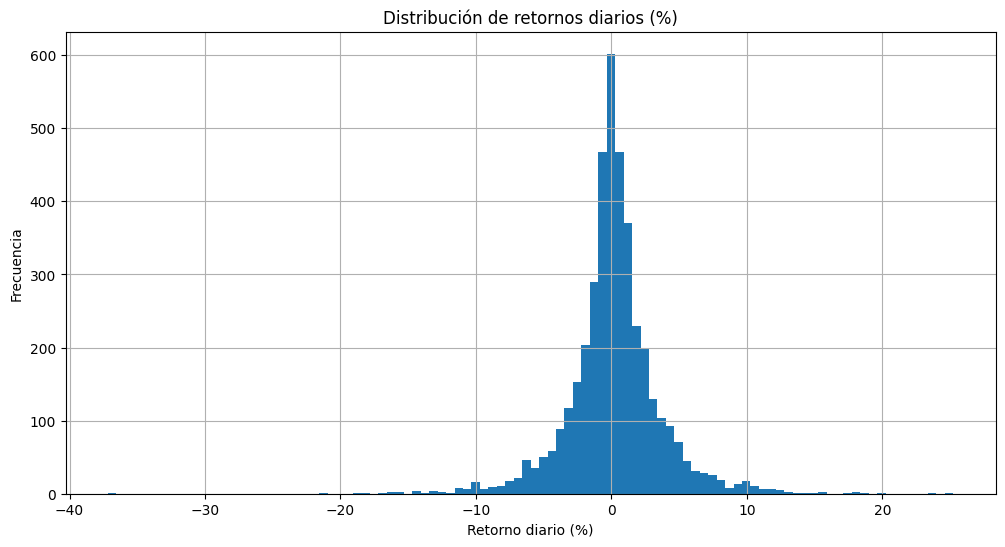

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6)) # Aumentamos el tamaño de la figura para mejor legibilidad
plt.hist(df["retorno_pct"].dropna(), bins=100)
plt.title("Distribución de retornos diarios (%)")
plt.xlabel("Retorno diario (%)")
plt.ylabel("Frecuencia")
plt.grid(True) # Añadimos una cuadrícula
plt.show()

In [7]:
df["retorno_pct"].describe()


,retorno_pct
count,4127.000000
mean,0.195074
std,3.508355
min,-37.169539
25%,-1.234595
50%,0.118286
75%,1.600544
max,25.247169


In [8]:
print(f"Asimetría (Skewness): {df['retorno_pct'].skew()}")
print(f"Curtosis (Kurtosis): {df['retorno_pct'].kurtosis()}")

Asimetría (Skewness): -0.11883207765131429
Curtosis (Kurtosis): 7.97500858454333


## Pregunta 2:

¿Cuál es su nivel de volatilidad diaria y anual?

Esto nos dirános dará información clave sobre la estabilidad del precio del activo y el riesgo asociado a sus movimientos.

In [9]:
# Volatilidad diaria promedio

# La volatilidad diaria es simplemente la desviación estándar de los retornos diarios.

vol_diaria = df["retorno_pct"].std()

print(f"Volatilidad diaria promedio: {vol_diaria:.2f}%")

Volatilidad diaria promedio: 3.51%


In [10]:
# Volatilidad anualizada

# En finanzas, la volatilidad anual se calcula como:

# (252 días bursátiles como convención estándar)

vol_anual = vol_diaria * np.sqrt(252)

print(f"Volatilidad anualizada: {vol_anual:.2f}%")

Volatilidad anualizada: 55.69%


In [11]:
# Volatilidad anual histórica (más profesional)

# Ahora calculamos la volatilidad por año calendario:

df["año"] = df["fecha"].dt.year

vol_por_año = df.groupby("año")["retorno_pct"].std() * np.sqrt(252)

print(vol_por_año)

año
2015    57.213154
2016    39.901741
2017    79.244210
2018    67.356515
2019    56.550914
2020    59.859944
2021    66.816000
2022    52.796688
2023    36.365280
2024    44.495414
2025    34.832221
2026    47.230939
Name: retorno_pct, dtype: float64


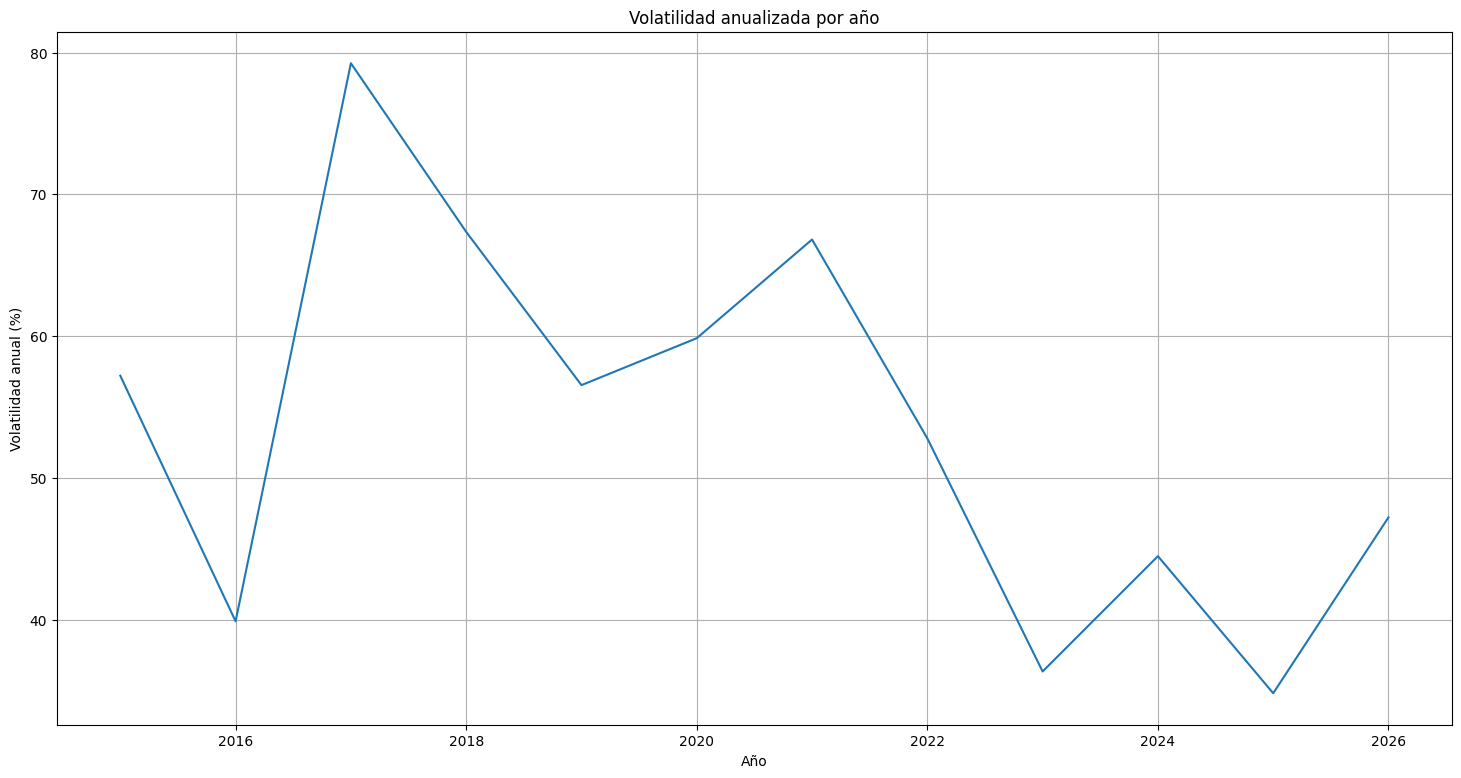

In [12]:
#Gráfico de volatilidad anual

plt.figure(figsize=(18, 9))
plt.plot(vol_por_año.index, vol_por_año.values)
plt.title("Volatilidad anualizada por año")
plt.xlabel("Año")
plt.ylabel("Volatilidad anual (%)")
plt.grid(True)
plt.show()

## Pregunta 3:

¿Con qué frecuencia ocurren movimientos extremos?

Esto nos permitirá evaluar qué tan frecuentes son las variaciones bruscas del precio y medir el nivel de inestabilidad del activo.

In [13]:
# Ya definimos:

# df["evento_extremo"] = df["retorno_pct"].abs() > 5

#Ahora lo cuantificamos formalmente.

# Cantidad total de eventos extremos
total_eventos = df["evento_extremo"].sum()
print("Total de eventos extremos:", total_eventos)

Total de eventos extremos: 492


In [14]:
# Porcentaje sobre el total de días
total_dias = len(df)

porcentaje_eventos = (total_eventos / total_dias) * 100

print(f"Porcentaje de días con eventos extremos: {porcentaje_eventos:.2f}%")

Porcentaje de días con eventos extremos: 11.92%


In [15]:
# Eventos extremos por año
eventos_por_año = df.groupby("año")["evento_extremo"].sum()

print(eventos_por_año)

año
2015    39
2016    21
2017    96
2018    74
2019    39
2020    40
2021    75
2022    37
2023    23
2024    27
2025    14
2026     7
Name: evento_extremo, dtype: int64


In [16]:
# Frecuencia relativa anual
dias_por_año = df.groupby("año")["evento_extremo"].count()

frecuencia_anual = (eventos_por_año / dias_por_año) * 100

print(frecuencia_anual)

año
2015    10.684932
2016     5.737705
2017    26.301370
2018    20.273973
2019    10.684932
2020    10.928962
2021    20.547945
2022    10.136986
2023     6.301370
2024     7.377049
2025     3.835616
2026     6.363636
Name: evento_extremo, dtype: float64


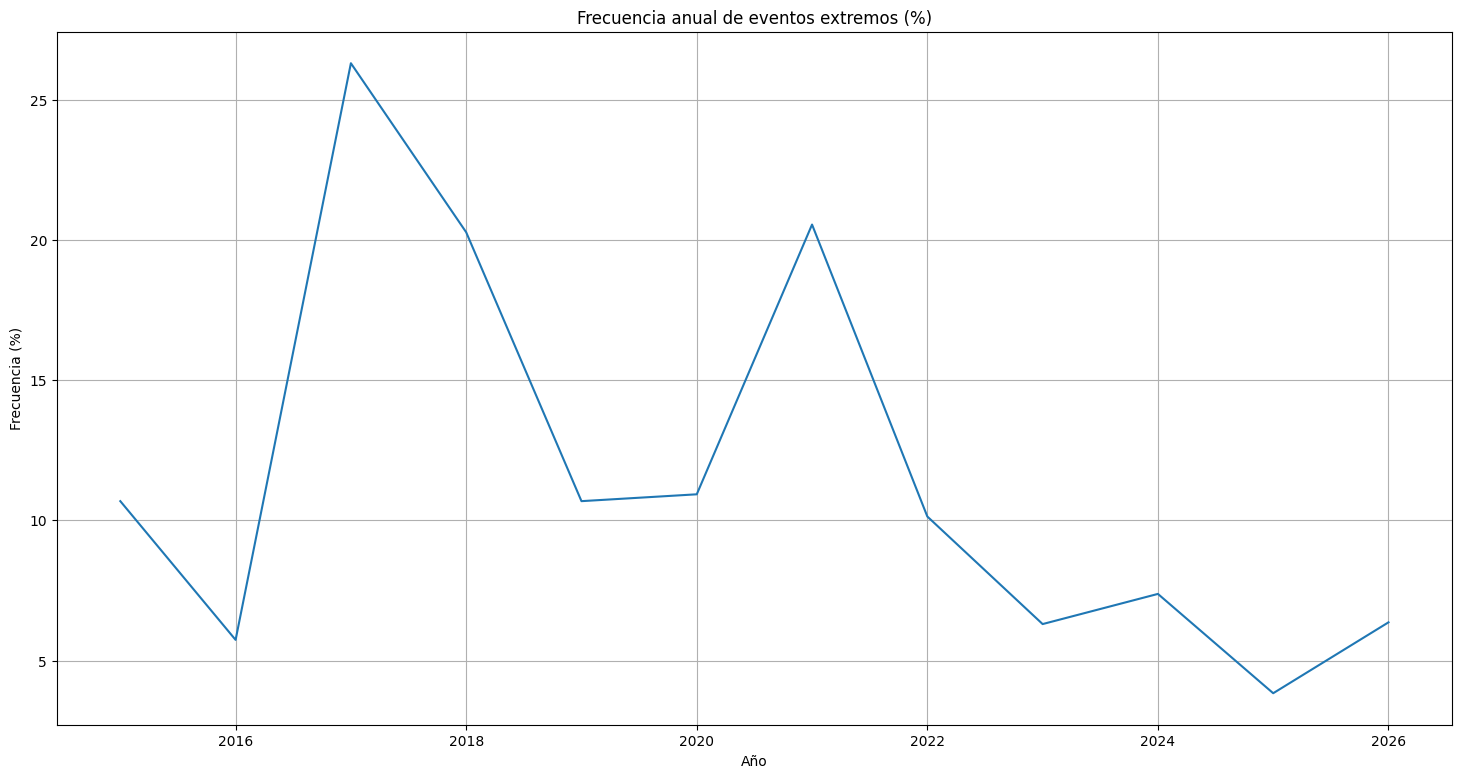

In [17]:
# Visualización

plt.figure(figsize=(18, 9))
plt.plot(frecuencia_anual.index, frecuencia_anual.values)
plt.title("Frecuencia anual de eventos extremos (%)")
plt.xlabel("Año")
plt.ylabel("Frecuencia (%)")
plt.grid(True)
plt.show()

## Pregunta 4:

¿Cuál ha sido la magnitud de sus principales caídas acumuladas?

Esto nos permitirá medir la profundidad de las caídas históricas y evaluar el nivel de riesgo asociado a los ciclos bajistas del activo.



In [18]:
# Calculamos el drawdown
# Aseguramos orden cronológico
df = df.sort_values("fecha").reset_index(drop=True)

# Máximo acumulado histórico
df["max_acumulado"] = df["cierre"].cummax()

# Drawdown porcentual
df["drawdown_pct"] = (df["cierre"] / df["max_acumulado"] - 1) * 100

In [19]:
# Magnitud del peor drawdown
max_drawdown = df["drawdown_pct"].min()

print(f"Drawdown máximo histórico: {max_drawdown:.2f}%")

# Ese número responde directamente a cual fue la peor caída acumulada

Drawdown máximo histórico: -83.40%


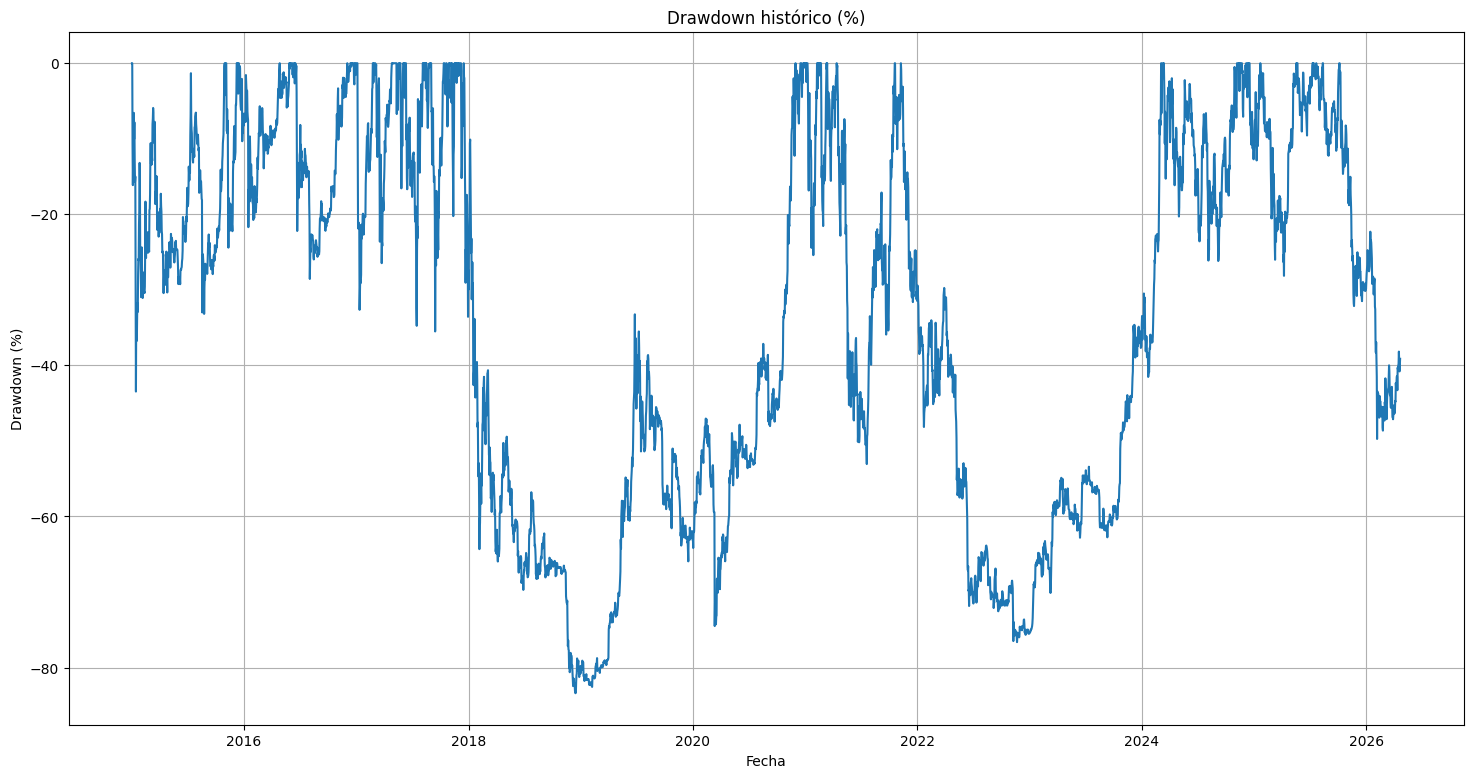

In [20]:
# Curva completa de drawdown

plt.figure(figsize=(18, 9))
plt.plot(df["fecha"], df["drawdown_pct"])
plt.title("Drawdown histórico (%)")
plt.xlabel("Fecha")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.show()

In [21]:
# Identificamos las principales caídas (Top 5)

# En vez de quedarnos solo con la peor, vamos a listar las más profundas.

top_drawdowns = df.nsmallest(5, "drawdown_pct")[["fecha", "drawdown_pct"]]

print(top_drawdowns)

# Esto te mostrará las fechas donde el mercado estuvo más deprimido respecto a su máximo previo.

          fecha  drawdown_pct
1444 2018-12-15    -83.399009
1443 2018-12-14    -83.369655
1445 2018-12-16    -83.316550
1442 2018-12-13    -83.004518
1498 2019-02-07    -82.564488


## Pregunta 5:

¿Existe relación entre variaciones fuertes de precio y cambios en el volumen negociado?


Esto nos permitirá determinar si los movimientos bruscos de precio están acompañados por cambios significativos en la actividad del mercado.


In [22]:
# Ahora cruzamos:

# -retorno_pct
# -cambio_volumen_pct
# -evento_extremo

# Análisis relacional

# Correlación simple precio–volumen
correlacion = df["retorno_pct"].corr(df["cambio_volumen_pct"])

print(f"Correlación entre retorno y cambio de volumen: {correlacion:.4f}")

Correlación entre retorno y cambio de volumen: 0.0323


In [23]:
# ¿El volumen cambia más en días extremos?

# Comparamos volumen en días normales vs extremos.

vol_extremos = df[df["evento_extremo"]]["cambio_volumen_pct"].mean()
vol_normales = df[~df["evento_extremo"]]["cambio_volumen_pct"].mean()

print(f"Cambio promedio volumen en días extremos: {vol_extremos:.2f}%")
print(f"Cambio promedio volumen en días normales: {vol_normales:.2f}%")

Cambio promedio volumen en días extremos: 37.12%
Cambio promedio volumen en días normales: 1.84%


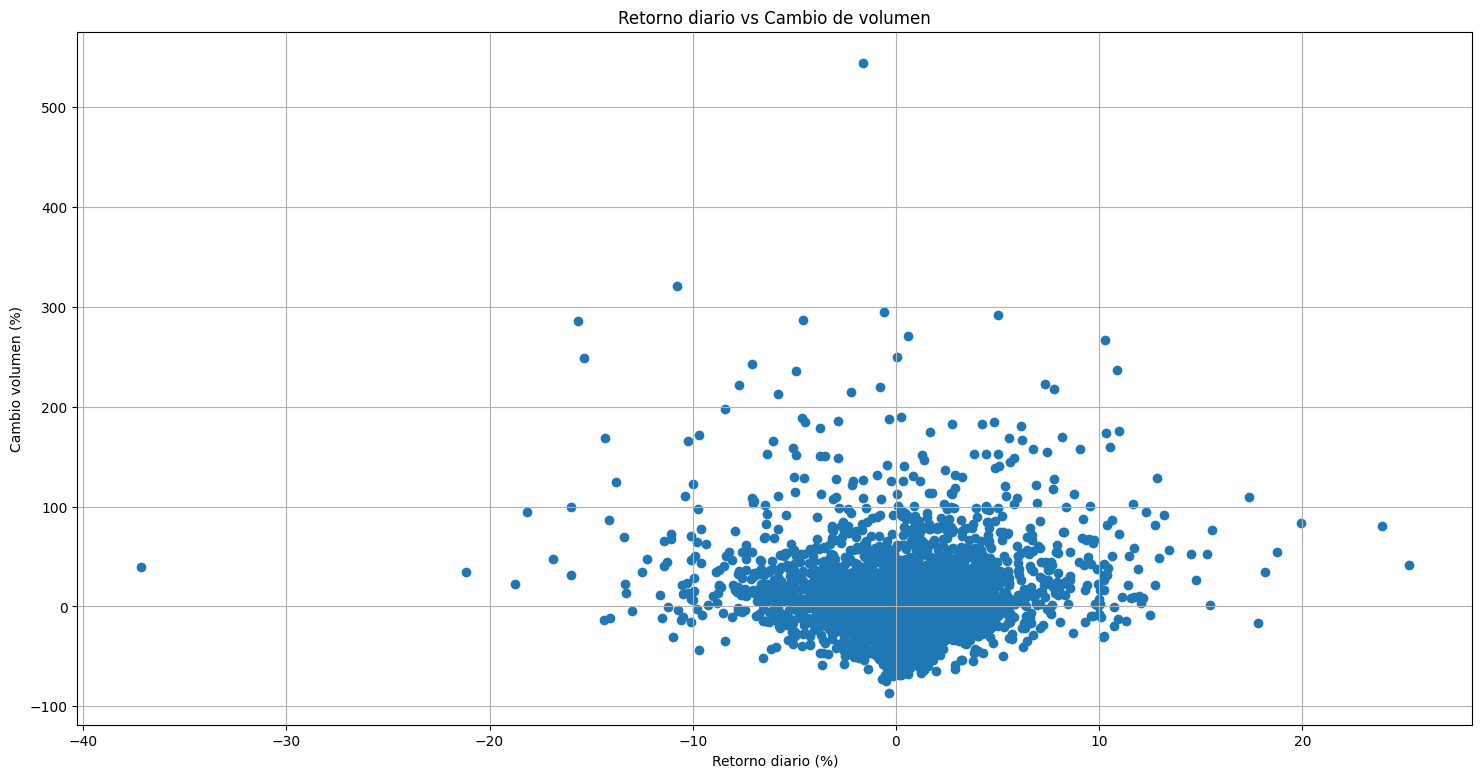

In [24]:
# Visualización dispersión (scatter plot)

plt.figure(figsize=(18, 9))
plt.scatter(df["retorno_pct"], df["cambio_volumen_pct"])
plt.title("Retorno diario vs Cambio de volumen")
plt.xlabel("Retorno diario (%)")
plt.ylabel("Cambio volumen (%)")
plt.grid(True)
plt.show()

## Pregunta 6:

¿El volumen aumenta durante períodos de alta volatilidad?

Esto nos permitirá evaluar si los períodos de mayor incertidumbre están asociados con un incremento sostenido en la actividad de negociación.



In [25]:
# Ahora no miramos días extremos aislados, sino regímenes de alta volatilidad.

# Vamos a trabajar con:

# - volatilidad_movil_30d

# - cambio_volumen_pct

In [26]:
# Correlación entre volatilidad y volumen

# Primero vemos si existe relación lineal:

correlacion_vol = df["volatilidad_movil_30d"].corr(df["cambio_volumen_pct"])

print(f"Correlación entre volatilidad móvil y cambio de volumen: {correlacion_vol:.4f}")

Correlación entre volatilidad móvil y cambio de volumen: -0.0327


In [27]:
# Comparar períodos de alta vs baja volatilidad

# Definimos alta volatilidad como valores por encima del percentil 75:

umbral_alta_vol = df["volatilidad_movil_30d"].quantile(0.75)

df["alta_volatilidad"] = df["volatilidad_movil_30d"] > umbral_alta_vol

# Ahora comparamos volumen:

vol_alta = df[df["alta_volatilidad"]]["cambio_volumen_pct"].mean()
vol_baja = df[~df["alta_volatilidad"]]["cambio_volumen_pct"].mean()

print(f"Cambio promedio de volumen en alta volatilidad: {vol_alta:.2f}%")
print(f"Cambio promedio de volumen en baja volatilidad: {vol_baja:.2f}%")

Cambio promedio de volumen en alta volatilidad: 3.13%
Cambio promedio de volumen en baja volatilidad: 7.01%


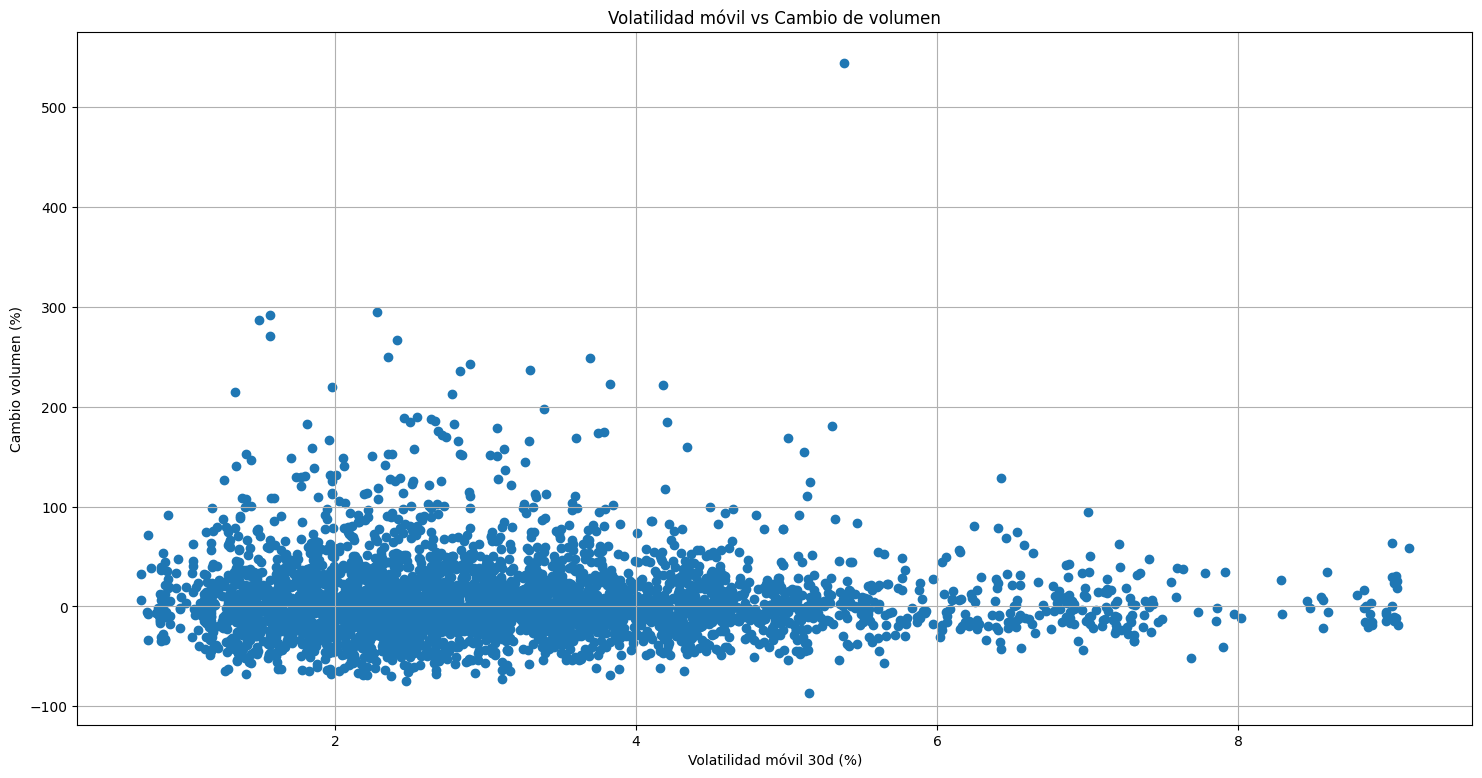

In [28]:
# Visualización

plt.figure(figsize=(18, 9))
plt.scatter(df["volatilidad_movil_30d"], df["cambio_volumen_pct"])
plt.title("Volatilidad móvil vs Cambio de volumen")
plt.xlabel("Volatilidad móvil 30d (%)")
plt.ylabel("Cambio volumen (%)")
plt.grid(True)
plt.show()

## CONCLUSIONES DEL ANÁLISIS

El estudio analiza el comportamiento histórico de Bitcoin a través de retornos diarios, volatilidad, eventos extremos, drawdowns y relación con el volumen negociado.

### 1- Distribución de retornos diarios

* Los retornos diarios presentan:

* Media: 0.19%

* Desviación estándar: 3.52%

* Curtosis: 7.96

* Asimetría: -0.12

La curtosis elevada indica presencia de colas pesadas, lo que implica mayor probabilidad de eventos extremos que en una distribución normal.

La asimetría ligeramente negativa sugiere que las caídas fuertes tienden a ser marginalmente más pronunciadas que las subidas extremas.

*Conclusión*: Bitcoin no sigue una distribución normal y presenta alta probabilidad de movimientos abruptos.

### 2- Volatilidad diaria y anual

* Volatilidad diaria promedio: 3.52%

* Volatilidad anualizada: 55.91%

Se observan años con volatilidad superior al 70% (ej. 2017), y períodos más moderados cercanos al 35%.

*Conclusión*: Bitcoin exhibe volatilidad estructuralmente elevada, muy superior a activos tradicionales, lo que implica alto riesgo pero también potencial de rendimiento.

### 3- Frecuencia de movimientos extremos

* Total eventos >5%: 489

Representan 12.03% de los días

En 2017 y 2018 la frecuencia superó el 20% anual.

*Conclusión*: Aproximadamente 1 de cada 8 días presenta movimientos extremos, confirmando alta inestabilidad diaria.

### 4- Magnitud de principales caídas acumuladas

* Drawdown máximo histórico: -83.40%

Ocurrió en diciembre de 2018.

Esto implica que desde un máximo histórico el precio llegó a perder más del 80% antes de recuperar.

*Conclusión*: Bitcoin presenta caídas acumuladas extremadamente profundas, lo que evidencia alto riesgo temporal para inversores.

### 5- Relación entre retornos y volumen

* Correlación retorno–volumen: 0.0298 (muy baja)

* Cambio promedio volumen en días extremos: 37.01%

* En días normales: 1.78%

Aunque la correlación lineal es débil, los días extremos muestran aumentos significativos en volumen.

*Conclusión*: Los shocks de precio están acompañados por fuerte actividad de mercado.

### 6- Volumen durante períodos de alta volatilidad

* Correlación volatilidad–volumen: -0.0332

* Volumen promedio en alta volatilidad: 2.98%

* En baja volatilidad: 7.02%

No se observa relación positiva estructural entre regímenes de alta volatilidad y aumento sostenido de volumen.

*Conclusión*: El volumen reacciona a shocks puntuales más que a regímenes prolongados de volatilidad elevada.



## RESUMEN EJECUTIVO

Bitcoin presenta:

* Alta volatilidad estructural (~56% anual)

* Frecuencia elevada de movimientos extremos (12% de los días)

* Drawdowns históricos profundos (-83%)

* Aumento significativo del volumen en días de shock

* Ausencia de relación fuerte entre volatilidad prolongada y volumen

En términos generales:

Bitcoin es un activo de alto riesgo y alta variabilidad, caracterizado por episodios recurrentes de movimientos extremos y ciclos profundos de caída, aunque con fuerte crecimiento en el largo plazo.

El volumen actúa como amplificador en días críticos, pero no necesariamente aumenta de forma sostenida durante períodos prolongados de volatilidad.

## CIERRE

El análisis confirma que Bitcoin no se comporta como un activo tradicional, ya que presenta colas pesadas en la distribución de sus retornos y un nivel de riesgo extremo. Asimismo, exhibe ciclos de mercado pronunciados, con fases expansivas y contractivas marcadas, lo que implica que su inversión requiere una elevada tolerancia al riesgo y capacidad para soportar fuertes fluctuaciones temporales.

# MODELADO PREDICTIVO

### Definición del problema

En esta etapa se plantea un problema de Machine Learning de tipo regresión. El objetivo es predecir el retorno porcentual diario del activo a partir de variables explicativas como el volumen, la volatilidad y cambios en el comportamiento del mercado.

La variable objetivo (retorno_pct) es continua, por lo que se utilizan modelos de regresión.

Este enfoque permite pasar de un análisis descriptivo a uno predictivo, con el fin de explorar la capacidad de las variables disponibles para anticipar comportamientos futuros del mercado.

### Hipótesis de trabajo

Dado que los retornos financieros suelen presentar un alto nivel de aleatoriedad, se espera que la capacidad predictiva de los modelos sea limitada.

Sin embargo, se evaluará si las variables seleccionadas contienen información suficiente para capturar patrones útiles.

### Librerías utilizadas

A continuación se importan las principales librerías utilizadas a lo largo del análisis exploratorio, la preparación de los datos y el modelado de Machine Learning.

Estas herramientas permiten realizar manipulación de datos, visualización, entrenamiento de modelos, validación y reducción de dimensionalidad.

In [29]:
# ==============================
# Manipulación de datos
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualización
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Modelado y evaluación
# ==============================
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================
# Boosting
# ==============================
from xgboost import XGBRegressor

# ==============================
# Reducción de dimensionalidad
# ==============================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==============================
# Configuración visual
# ==============================
sns.set(style="whitegrid")

### Preparación de datos para Machine Learning

En esta etapa se preparan los datos para el entrenamiento de modelos de Machine Learning.

Primero, se eliminan los valores nulos para evitar errores en el entrenamiento y mejorar la calidad del dataset.

Luego, se definen las variables predictoras (X), que incluyen indicadores relevantes del comportamiento del mercado como el volumen, la volatilidad y sus variaciones.

Finalmente, se define la variable objetivo (y), que corresponde al retorno porcentual diario, el cual se busca predecir.

También se verifica que ambas estructuras tengan la misma cantidad de observaciones, garantizando la consistencia del dataset antes del modelado.

In [30]:
# Eliminamos valores nulos
df_model = df.dropna()

# Variables predictoras
X = df_model[[
    "volumen",
    "volatilidad_movil_30d",
    "cambio_volumen_pct"
]]

# Variable objetivo
y = df_model["retorno_pct"]

# Chequeo de consistencia
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Shape de X: (4098, 3)
Shape de y: (4098,)


### Modelo 1: Regresión Lineal

Se entrenó un modelo de regresión lineal como baseline para predecir la variable objetivo `retorno_pct`.

Este modelo asume una relación lineal entre las variables predictoras y la variable objetivo, por lo que presenta baja complejidad (alto bias y baja varianza).

Se evaluó su desempeño utilizando las siguientes métricas:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (Coeficiente de determinación)

Los resultados obtenidos permiten analizar si el modelo logra capturar la relación entre las variables o si presenta underfitting.

In [31]:
# Inicializamos el modelo
lr = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
lr.fit(X_train, y_train)

# Generamos predicciones sobre el conjunto de test
y_pred_lr = lr.predict(X_test)

print(y_pred_lr[:5])

[0.06029635 0.39207547 0.08408607 0.20497471 0.18487079]


In [32]:
# Evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 3.5040022571302876
MAE: 2.3045408521305912
R2: 0.004624398711375433


### Interpretación del modelo

El modelo de regresión lineal presenta un desempeño limitado, con un valor de R² cercano a 0 (0.0046), lo que indica que prácticamente no logra explicar la variabilidad de la variable objetivo.

Asimismo, los valores de RMSE (3.50) y MAE (2.30) sugieren que el error de predicción es relativamente alto en comparación con la magnitud de los datos.

Estos resultados indican la presencia de **underfitting**, ya que el modelo es demasiado simple para capturar la complejidad del problema.

Esto sugiere que la relación entre las variables predictoras y el retorno no es puramente lineal, por lo que será necesario evaluar modelos más complejos que permitan capturar patrones no lineales.

En la siguiente etapa se implementarán modelos más avanzados para mejorar la capacidad predictiva y analizar el trade-off entre bias y varianza.

### Modelo 2: Random Forest

Se entrena un modelo de Random Forest, un método de ensamble basado en múltiples árboles de decisión.

A diferencia de la regresión lineal, este modelo puede capturar relaciones no lineales entre las variables, lo que lo hace más flexible y potente.

Random Forest reduce el sesgo (bias) del modelo al combinar múltiples estimadores, aunque puede incrementar la varianza si no se controla adecuadamente.

Este modelo permite evaluar si un enfoque más complejo mejora el rendimiento predictivo en comparación con el baseline.

In [33]:
# Inicializamos el modelo
rf = RandomForestRegressor(random_state=42)

# Entrenamos
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Evalucaion comparativa

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE RF:", rmse_rf)
print("MAE RF:", mae_rf)
print("R2 RF:", r2_rf)

RMSE RF: 3.6935258497505092
MAE RF: 2.4322532453521823
R2 RF: -0.1059628074666783


### Interpretación del modelo Random Forest

El modelo Random Forest presenta un desempeño peor en comparación con la regresión lineal.

Se observa un RMSE de 3.69 y un MAE de 2.43, lo que indica una menor capacidad predictiva respecto al modelo baseline.

El valor de R² (-0.10) sugiere que el modelo no logra explicar la variabilidad de los datos e incluso presenta un rendimiento inferior al de una predicción basada en la media.

Esto indica que, a pesar de ser un modelo más complejo, no está capturando correctamente las relaciones presentes en los datos.

Este comportamiento puede estar asociado a problemas de overfitting o a la falta de variables relevantes que permitan mejorar la capacidad predictiva del modelo.

### Modelo 3: Boosting (XGBoost)

En esta etapa se entrena un modelo basado en Boosting utilizando XGBoost, uno de los algoritmos más potentes para problemas de regresión en datos tabulares.

A diferencia de modelos como Random Forest, que construyen árboles de forma independiente, XGBoost entrena los modelos de manera secuencial, donde cada nuevo árbol corrige los errores del anterior.

Esto permite reducir tanto el sesgo (bias) como mejorar la capacidad predictiva del modelo.

El objetivo es evaluar si un modelo más sofisticado logra capturar mejor las relaciones en los datos y mejorar las métricas obtenidas previamente.

In [34]:
# Creamos el modelo
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Entrenamos
xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("RMSE XGB:", rmse_xgb)
print("MAE XGB:", mae_xgb)
print("R2 XGB:", r2_xgb)

RMSE XGB: 3.696013372645468
MAE XGB: 2.386965766741362
R2 XGB: -0.10745300102545396


### Interpretación del modelo XGBoost

El modelo XGBoost presenta un desempeño peor en comparación con los modelos anteriores.

Se observa un RMSE de 3.69 y un MAE de 2.38, lo que indica una menor capacidad predictiva respecto a la regresión lineal.

El valor de R² (-0.10) sugiere que el modelo no logra explicar la variabilidad de los datos, mostrando un rendimiento incluso inferior al de una predicción basada en la media.

Esto indica que, a pesar de utilizar un modelo más avanzado basado en Boosting, no se están capturando correctamente las relaciones presentes en los datos.

Este comportamiento sugiere que el problema no radica en la elección del modelo, sino en la falta de variables relevantes o en la baja señal predictiva de las variables utilizadas.

En términos del trade-off Bias–Varianza, se observa que aumentar la complejidad del modelo no reduce el error, lo que indica una limitación en la información disponible para el aprendizaje.

### Validación cruzada del modelo

Para evaluar la capacidad de generalización del modelo, se aplica validación cruzada (K-Fold Cross Validation).

Esta técnica permite entrenar y evaluar el modelo múltiples veces utilizando diferentes particiones de los datos, obteniendo una estimación más robusta del rendimiento.

Esto es clave para detectar problemas como overfitting o underfitting, y está directamente relacionado con el trade-off Bias–Varianza.

In [35]:
# Validacion cruzada
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("RMSE por fold:", -scores)
print("RMSE promedio:", -scores.mean())

RMSE por fold: [3.18894012 4.72859284 3.97255819 3.03748511 3.11020082]
RMSE promedio: 3.607555416692007


### Interpretación de la validación cruzada

La validación cruzada muestra un RMSE promedio de 3.61, con cierta variabilidad entre los folds.

Si bien existe variación en los resultados, los valores se mantienen dentro de un rango razonable, lo que indica que el modelo presenta un comportamiento relativamente estable.

Además, el RMSE obtenido es similar al observado en el conjunto de test, lo que sugiere que el modelo no presenta un problema severo de overfitting.

Sin embargo, el nivel de error sigue siendo elevado, lo que indica que el modelo no logra capturar correctamente los patrones en los datos.

Esto sugiere que la principal limitación no está en el modelo en sí, sino en la calidad o relevancia de las variables utilizadas, lo cual impacta directamente en el trade-off Bias–Varianza.

### Optimización de hiperparámetros

En esta etapa se realiza la optimización de hiperparámetros del modelo Random Forest utilizando RandomizedSearchCV.

Los hiperparámetros son configuraciones del modelo que no se aprenden a partir de los datos, sino que deben definirse antes del entrenamiento.

El objetivo es encontrar la combinación de parámetros que minimice el error del modelo, mejorando su capacidad predictiva.

Se utiliza Randomized Search en lugar de Grid Search debido a su mayor eficiencia, ya que permite explorar distintas combinaciones de forma aleatoria sin evaluar todas las posibles configuraciones.

Este proceso también contribuye a mejorar el equilibrio del modelo en términos del trade-off Bias–Varianza.

In [36]:
# Definimos el espacio de búsqueda de hiperparámetros
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
}

# Configuramos la búsqueda
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

# Entrenamos la búsqueda
search.fit(X_train, y_train)

# Mejor modelo encontrado
best_rf = search.best_estimator_

print("Mejores parámetros:", search.best_params_)


Mejores parámetros: {'n_estimators': 300, 'max_depth': 5}


### Función de evaluación de modelos

Se define una función auxiliar para evaluar el desempeño de los modelos de Machine Learning.

Esta función permite calcular métricas clave de regresión:

- RMSE (Root Mean Squared Error): mide el error promedio penalizando más los errores grandes.
- MAE (Mean Absolute Error): mide el error promedio absoluto.
- R² (Coeficiente de determinación): indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

Definir esta función permite reutilizar el código y mantener consistencia en la comparación entre modelos.

In [37]:
# Definicion de fuuncion evaluar
def evaluar(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print("\n")

### Evaluación del modelo optimizado

Se evalúa el modelo Random Forest optimizado utilizando los mejores hiperparámetros encontrados mediante RandomizedSearchCV.

El objetivo es analizar si la optimización permite mejorar el desempeño del modelo en comparación con su versión original.

Esto permite validar si el ajuste de hiperparámetros logra mejorar el equilibrio entre bias y varianza.

In [38]:
# Evaluacion
y_pred_best = best_rf.predict(X_test)

evaluar(y_test, y_pred_best, "Random Forest Optimizado")

--- Random Forest Optimizado ---
RMSE: 3.5103
MAE: 2.3016
R2: 0.0011




### Interpretación del modelo Random Forest optimizado

El modelo Random Forest optimizado muestra una mejora significativa respecto a la versión original del modelo, reduciendo el error y alcanzando métricas similares a las de la regresión lineal.

Se observa un RMSE de 3.51 y un MAE de 2.30, mientras que el R² (0.001) indica una capacidad muy limitada para explicar la variabilidad de los datos.

La optimización de hiperparámetros llevó a una reducción en la complejidad del modelo (max_depth=5), lo que sugiere que el modelo original presentaba un nivel alto de varianza.

Esto refleja un mejor equilibrio en el trade-off Bias–Varianza, logrando un modelo más estable y con mejor capacidad de generalización.

Sin embargo, el hecho de que el modelo optimizado no supere al modelo lineal indica que la principal limitación no está en el algoritmo, sino en la baja capacidad predictiva de las variables utilizadas.

A continuación se presenta una comparación de las métricas de desempeño obtenidas para cada modelo evaluado, incluyendo RMSE, MAE y R².

Esta tabla permite identificar de forma clara cuál modelo presenta mejor capacidad predictiva.

In [39]:
df_resultados = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "XGBoost", "Random Forest Opt"],
    "RMSE": [rmse, rmse_rf, rmse_xgb, 3.5104],
    "MAE": [mae, mae_rf, mae_xgb, 2.3018],
    "R2": [r2, r2_rf, r2_xgb, 0.0010]
})

df_resultados

,Modelo,RMSE,MAE,R2
0,Linear Regression,3.504002,2.304541,0.004624
1,Random Forest,3.693526,2.432253,-0.105963
2,XGBoost,3.696013,2.386966,-0.107453
3,Random Forest Opt,3.510400,2.301800,0.001000


### Análisis comparativo de modelos

Se evaluaron distintos modelos de Machine Learning para predecir el retorno diario, incluyendo regresión lineal, Random Forest y XGBoost.

Los resultados muestran que la regresión lineal presenta un desempeño similar o superior a los modelos más complejos, alcanzando el menor RMSE y el mejor valor de R² entre los modelos evaluados.

Por su parte, el modelo Random Forest en su versión original mostró un peor rendimiento, lo que sugiere un posible problema de sobreajuste debido a su alta complejidad.

Luego de la optimización de hiperparámetros, el modelo Random Forest mejoró su desempeño al reducir su complejidad (max_depth=5), logrando resultados similares al modelo lineal. Esto indica una reducción de la varianza y un mejor equilibrio en el trade-off Bias–Varianza.

Sin embargo, el modelo XGBoost tampoco logró mejorar los resultados, mostrando un desempeño inferior al baseline.

En conjunto, estos resultados sugieren que el aumento en la complejidad de los modelos no se traduce en una mejora en la capacidad predictiva.

Esto indica que la principal limitación del problema no está en los algoritmos utilizados, sino en la baja capacidad explicativa de las variables disponibles.

### Importancia de variables (Random Forest)

Se analiza la importancia de cada variable en el modelo Random Forest, lo que permite identificar cuáles tienen mayor impacto en la predicción del retorno.

Esto ayuda a interpretar el modelo y validar las decisiones tomadas en la ingeniería de atributos.

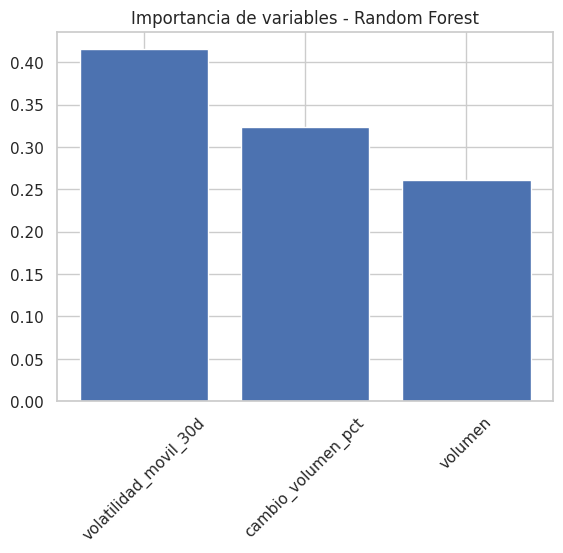

                 feature  importancia
1  volatilidad_movil_30d     0.415389
2     cambio_volumen_pct     0.323848
0                volumen     0.260763


In [40]:
# Importancia de variables (Random Forest)
importancias = best_rf.feature_importances_

features = X.columns

df_importancia = pd.DataFrame({
    "feature": features,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

# gráfico
plt.figure()
plt.bar(df_importancia["feature"], df_importancia["importancia"])
plt.title("Importancia de variables - Random Forest")
plt.xticks(rotation=45)
plt.show()

print(df_importancia)

### Interpretación de la importancia de variables

El modelo Random Forest indica que la variable más influyente en la predicción del retorno es la volatilidad_movil_30d, con una importancia aproximada del 41%.

En segundo lugar se encuentra cambio_volumen_pct (32%), seguida por volumen (26%).

Esto sugiere que las variables relacionadas con la variabilidad del mercado tienen mayor impacto en la predicción que el volumen en sí mismo.

Sin embargo, no se observa una dominancia absoluta de una sola variable, lo que indica que el modelo no encuentra un predictor fuertemente determinante.

Este resultado es consistente con el bajo desempeño general de los modelos, ya que sugiere que las variables disponibles tienen una capacidad limitada para explicar el comportamiento del retorno.

En términos del trade-off Bias–Varianza, esto refuerza la idea de que el problema presenta alto bias, dado que incluso modelos más complejos no logran capturar patrones claros en los datos.

### Análisis de Componentes Principales (PCA)

Se aplica PCA (Principal Component Analysis) con el objetivo de reducir la dimensionalidad del conjunto de variables y analizar la estructura de los datos.

PCA permite transformar las variables originales en nuevas variables llamadas componentes principales, que son combinaciones lineales de las variables originales y capturan la mayor varianza posible del dataset.

Este análisis permite:

- Identificar patrones en los datos
- Detectar redundancia entre variables
- Evaluar si es posible reducir la dimensionalidad sin perder información relevante

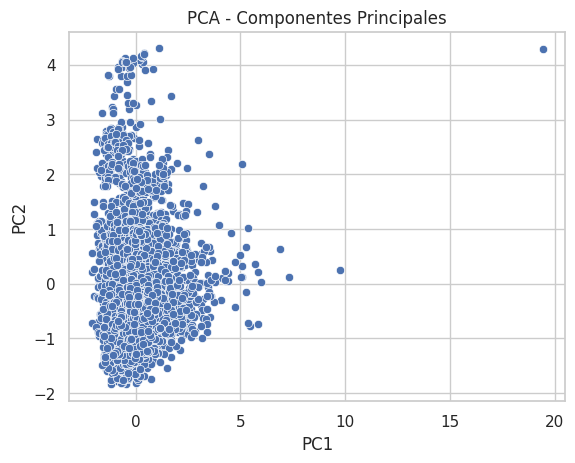

Varianza explicada por cada componente:
[0.40263629 0.33247664]


In [41]:
# Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA con 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Creamos DataFrame para visualizar
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Gráfico
plt.figure()
sns.scatterplot(x="PC1", y="PC2", data=df_pca)
plt.title("PCA - Componentes Principales")
plt.show()

# Varianza explicada
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

### Interpretación del PCA

Al observar la proyección de los datos en los dos primeros componentes principales (PC1 y PC2), no se identifican agrupamientos claros ni separaciones definidas entre observaciones.

La mayoría de los puntos se concentran en una región central, con una dispersión moderada y algunos valores atípicos (outliers), especialmente sobre el eje PC1.

Esto sugiere que las variables utilizadas no generan estructuras diferenciables en el espacio reducido, lo que indica una baja capacidad para capturar patrones relevantes en los datos.

La presencia de algunos puntos extremos refuerza la idea de que existen valores atípicos, pero no una estructura general que el modelo pueda aprender de forma consistente.

Este resultado es coherente con el bajo rendimiento de los modelos entrenados (R² cercano a 0), indicando que las variables no logran explicar adecuadamente la variabilidad del retorno.

En términos del trade-off Bias–Varianza, esto confirma que el problema presenta un alto bias, ya que incluso al transformar las variables en componentes principales no emergen patrones claros que permitan mejorar la capacidad predictiva del modelo.

### Conclusión final

En el presente trabajo se abordó un problema de regresión cuyo objetivo fue predecir el retorno porcentual diario a partir de variables vinculadas al comportamiento del mercado, tales como el volumen, la volatilidad y sus variaciones.

A lo largo del proceso se implementaron distintas técnicas de Machine Learning, incluyendo modelos lineales y no lineales como Regresión Lineal, Random Forest y XGBoost, junto con estrategias de validación cruzada y optimización de hiperparámetros. Esto permitió evaluar el desempeño de cada modelo y analizar su capacidad de generalización.

Los resultados obtenidos evidencian que los modelos más complejos no lograron superar el desempeño de la regresión lineal, la cual presentó las mejores métricas en términos de RMSE y R². Esto sugiere que el incremento en la complejidad del modelo no se traduce necesariamente en una mejora en la capacidad predictiva.

El modelo Random Forest optimizado mostró una mejora respecto a su versión inicial, especialmente al reducir su profundidad, lo que permitió un mejor equilibrio en el trade-off Bias–Varianza. Sin embargo, su rendimiento continuó siendo similar o inferior al modelo base. Por su parte, XGBoost tampoco logró mejorar los resultados, lo que refuerza la hipótesis de una baja señal predictiva en los datos.

El análisis de importancia de variables indicó que la volatilidad_movil_30d es el factor más relevante en la predicción, seguido por el cambio en el volumen, mientras que el volumen en sí presenta menor impacto. Esto sugiere que las variables relacionadas con la variabilidad del mercado aportan mayor información que los valores absolutos.

Asimismo, la aplicación de PCA permitió explorar la estructura de los datos, mostrando una alta dispersión y la ausencia de patrones claramente definidos en los primeros componentes principales. Esto refuerza la idea de que las variables actuales no capturan de forma adecuada la dinámica del fenómeno a predecir.

La validación cruzada confirmó que los modelos presentan un comportamiento relativamente estable, sin evidencias claras de overfitting, aunque con un nivel de error elevado, lo que indica un posible escenario de underfitting o falta de variables explicativas relevantes.

En conjunto, los resultados sugieren que la principal limitación del problema no radica en la elección del modelo, sino en la calidad y capacidad explicativa de las variables utilizadas.

Como líneas de mejora futuras, se propone ampliar el conjunto de variables mediante técnicas más avanzadas de ingeniería de atributos, incorporar nuevas fuentes de información (como indicadores macroeconómicos o variables externas) y profundizar en el uso de modelos de ensamble con un tuning más exhaustivo. Además, podría explorarse el uso de técnicas más avanzadas de reducción de dimensionalidad o modelos de series temporales.

Este trabajo permitió avanzar desde un análisis descriptivo hacia un enfoque predictivo, integrando conceptos fundamentales como validación de modelos, optimización de hiperparámetros, ensamble y el trade-off Bias–Varianza, esenciales en el desarrollo de soluciones de Machine Learning aplicadas a problemas reales.